In [1]:
import pandas as pd
import numpy as np

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_40204/2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("./datasets/Titanic/tested.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
# Fill in null space of age colume with median 
data["Age"].fillna(data["Age"].median(), inplace=True)

# Fill in null space of Fare with median
data["Fare"].fillna(data["Fare"].median(), inplace=True)

# Drop Cabin column because of to many null space
data.drop(columns=["Cabin"])

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_40204/2515352560.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_40204/2515352560.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_40204/2708602669.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=data ,palette="coolwarm")


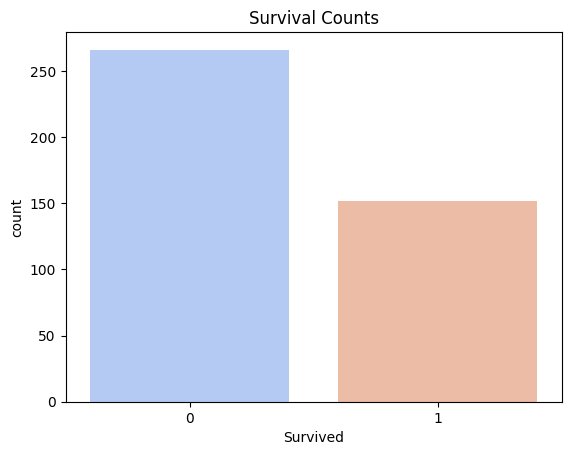

In [12]:
sns.countplot(x="Survived", data=data ,palette="coolwarm")
plt.title("Survival Counts")
plt.show()

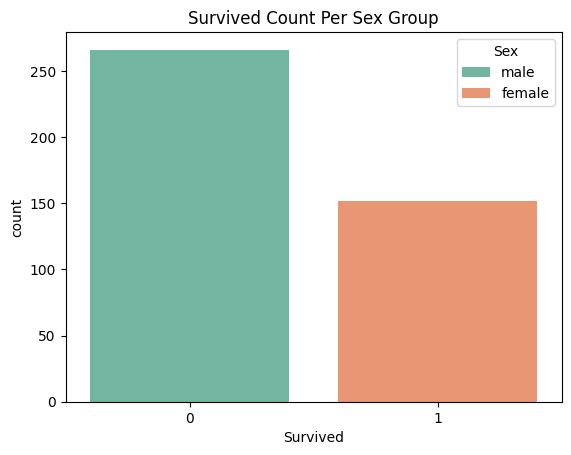

In [13]:
sns.countplot(x="Survived", hue="Sex", data=data, palette="Set2")
plt.title("Survived Count Per Sex Group")
plt.show()

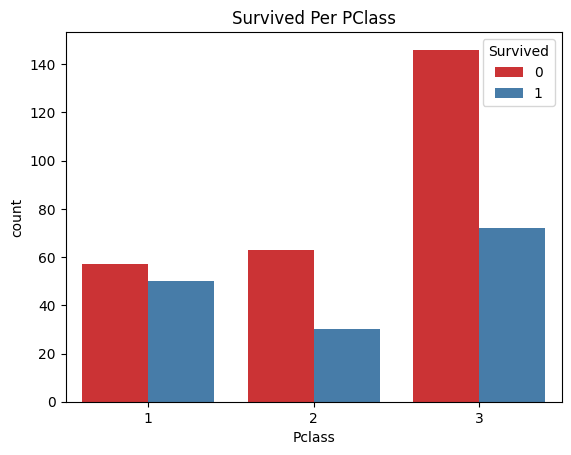

In [15]:
sns.countplot(x="Pclass", hue="Survived", data=data, palette="Set1")
plt.title("Survived Per PClass")
plt.show()

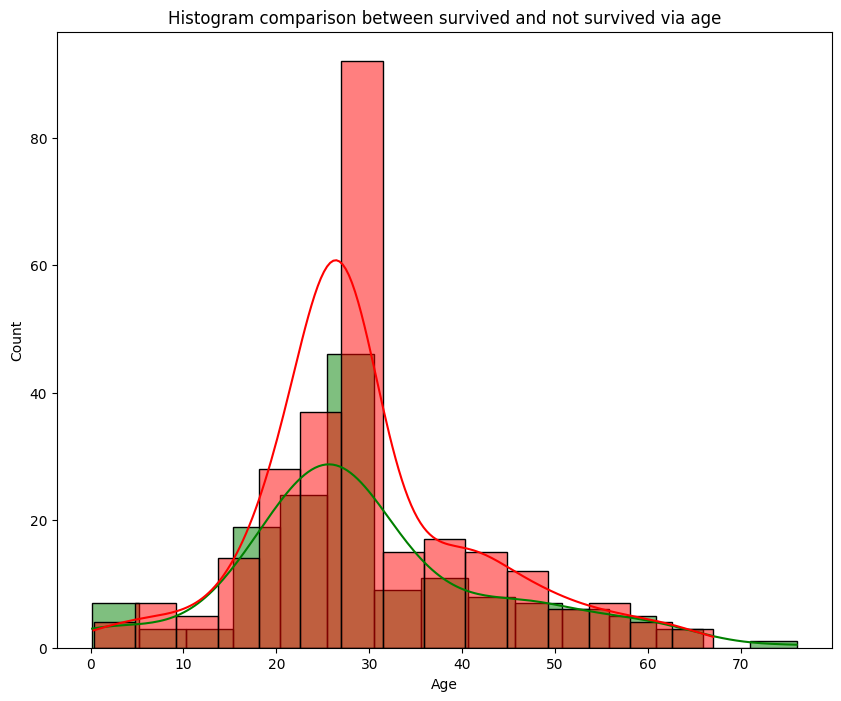

In [17]:
plt.figure(figsize=(10,8))
sns.histplot(data[data["Survived"]==1]["Age"], bins=15, color="green", label="Survived", kde=True)
sns.histplot(data[data["Survived"]==0]["Age"], bins=15, color="red", label="Not Survived", kde=True)
plt.title("Histogram comparison between survived and not survived via age")
plt.show()

/var/folders/ql/s803k9yn2l570nz7shf781y80000gn/T/ipykernel_40204/3058084946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=data, palette="Set2")


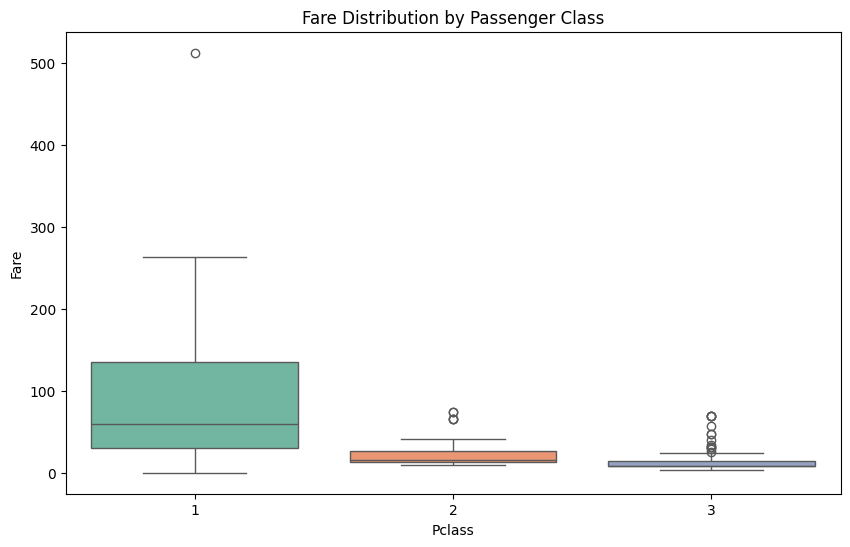

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Pclass", y="Fare", data=data, palette="Set2")
plt.title("Fare Distribution by Passenger Class")
plt.show()

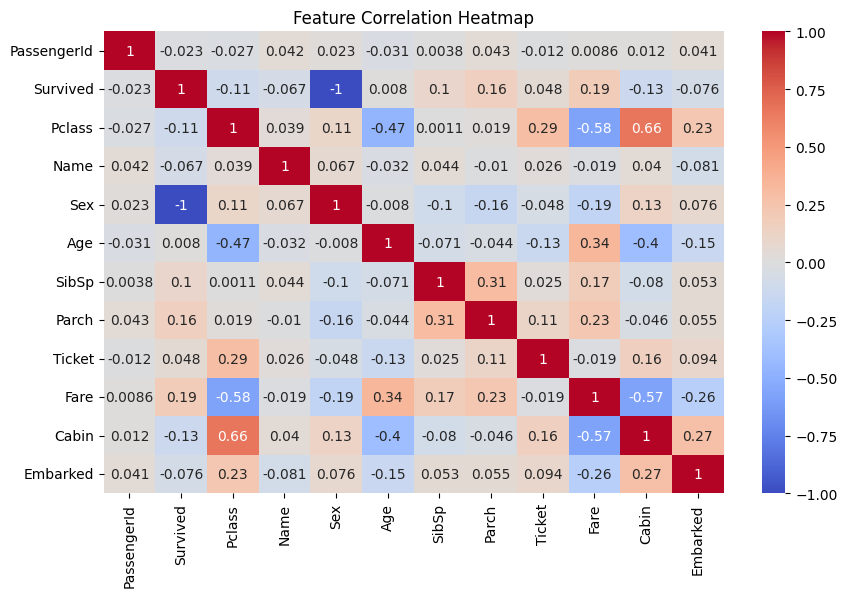

In [19]:
from sklearn.preprocessing import LabelEncoder

data_encoded = data.copy()
for col in data_encoded.select_dtypes(include='object'):
  data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])

plt.figure(figsize=(10,6))
sns.heatmap(data_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
data.columns = data.columns.str.strip()

cols_to_encode = [col for col in ['Sex', 'Embarked'] if col in data.columns]

if cols_to_encode:
  data = pd.get_dummies(data, columns=cols_to_encode, drop_first=True)

if all(col in data.columns for col in ['SibSp', 'Parch']):
  data['FamilySize'] = data['SibSp'] + data['Parch']

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,892,0,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,True,True,False,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,False,False,True,1
2,894,0,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,True,True,False,0
3,895,0,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,True,False,True,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,False,False,True,2


In [22]:
if 'FamilyiSize' not in data.columns:
  data['FamilySize'] = data['SibSp'] + data['Parch']
data['IsAlone'] = (data['FamilySize']==1).astype(int)

for col in ['Sex', 'Embarked']:
  if col in data.columns:
    data = pd.get_dummies(data, columns=col, drop_first=True)

feature_cols = ['Pclass','Age','Fare','Sex_male','Embarked_Q','Embarked_S','FamilySize','IsAlone']
X = data[[c for c in feature_cols if c in data.columns]]  
y = data['Survived']

print("Features X:\n", X.head())
print("\nTarget y:\n", y.head())

Features X:
    Pclass   Age     Fare  Sex_male  Embarked_Q  Embarked_S  FamilySize  \
0       3  34.5   7.8292      True        True       False           0   
1       3  47.0   7.0000     False       False        True           1   
2       2  62.0   9.6875      True        True       False           0   
3       3  27.0   8.6625      True       False        True           0   
4       3  22.0  12.2875     False       False        True           2   

   IsAlone  
0        0  
1        1  
2        0  
3        0  
4        0  

Target y:
 0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


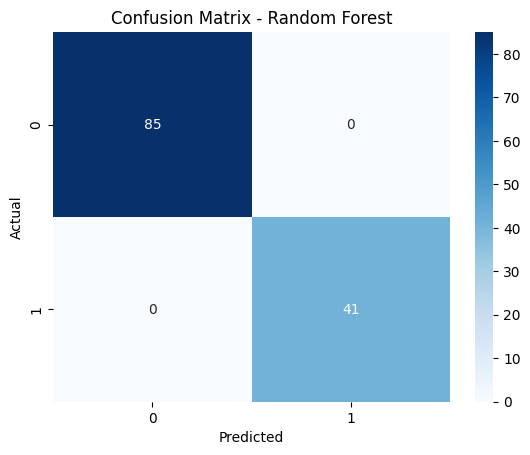

In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        85
           1       1.00      1.00      1.00        41

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



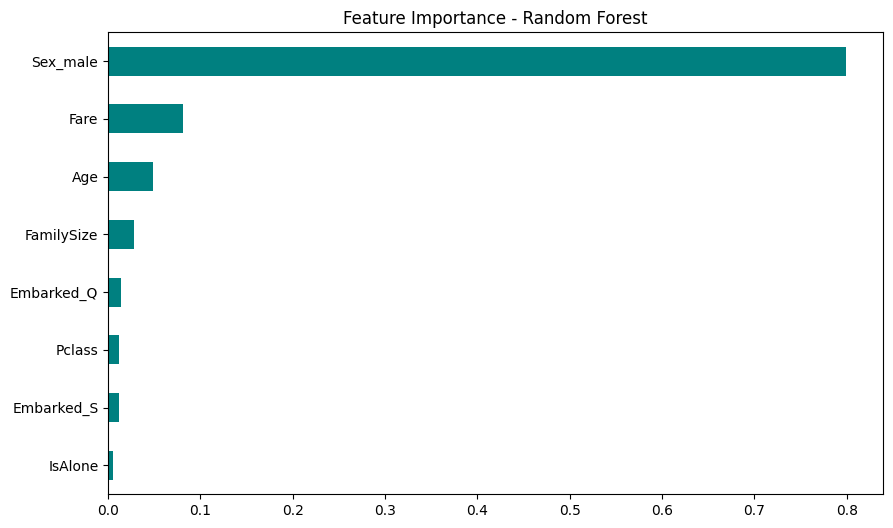

In [26]:
featuer_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
featuer_importance.sort_values().plot(kind='barh', figsize=(10,6), color='teal')
plt.title('Feature Importance - Random Forest')
plt.show()

# Conclusion
+ Females had higher survival rate than males.
+ Passengers in higher classes survived more.
+ Family size influenced survival: being alone slightly decreased survival chances.
+ Logistic Regression gives basic prediction, but Random Forest performed better.
+ Feature importance shows Fare, Sex, Pclass are top predictors.